In [13]:
import numpy as np 
import json
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [14]:
perp_index = [3, 9, 15, 21]
with_perp = False

#### Extract answer function

In [15]:
answer = "The cube is to the left from the perspective of the person in the image."
answer.split('The cube is to the ')[1].split(' from the perspective')[0]

'left'

In [16]:
def extract_answer(results):
    answers = []
    for item in results:
        text = item.get('text', '').lower()
        if "right" in text and "left" in text:
            print("both left and right in answer, entering manual check:", text)
            direction = input("Enter 'left' or 'right': ")
            answers.append(direction)
        else:
            if "left" in text:
                answers.append("left")
            elif "right" in text:
                answers.append("right")
            else:
                answers.append("unknown")
    return answers

In [17]:
# first 8 answers are left, last 8 are right
true_answers = ['left'] * 12 + ['right'] * 12

In [18]:
# repeat 0, 45, 60, 90, 120, 135, 180, 225, 240, 270, 300, 315
angles = [0, 45, 60, 90, 120, 135, 180, 225, 240, 270, 300, 315] * 2

In [19]:
if with_perp == False:
    angles_plot = [angles[i] for i in range(len(angles)) if i not in perp_index]
    true_answers_plot = [true_answers[i] for i in range(len(true_answers)) if i not in perp_index]
else:
    angles_plot = angles
    true_answers_plot = true_answers

### Base llava results first

In [20]:
base_results = {}

for n in range(10):
    base_results_path = f"data/evals/perspective_taking/answers/repeats/vpt_avatar_answers_base{n}.jsonl"
    with open(base_results_path, "r") as f:
        name = f"base_results_{n}"
        base_results[name] = [json.loads(line) for line in f.readlines()]

In [21]:
base_correct = {}

for name, results in base_results.items():
    base_answers = extract_answer(results)
    correct = [pred == true for pred, true in zip(base_answers, true_answers)]
    base_correct[name] = correct

In [22]:
# take average accuracy across the 10 base models
avg_base_correct = np.mean(list(base_correct.values()), axis=0)

if with_perp == False:
    avg_base_correct = [avg_base_correct[i] for i in range(len(avg_base_correct)) if i not in perp_index]
print("Average accuracy across 10 base models:", avg_base_correct)

Average accuracy across 10 base models: [1.0, 1.0, 1.0, 0.1, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.9, 0.9, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9, 1.0]


In [23]:
avg_base_correct

[1.0,
 1.0,
 1.0,
 0.1,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.9,
 0.9,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.9,
 1.0]

In [24]:
print("Average total accuracy:", np.mean(avg_base_correct))

Average total accuracy: 0.49000000000000005


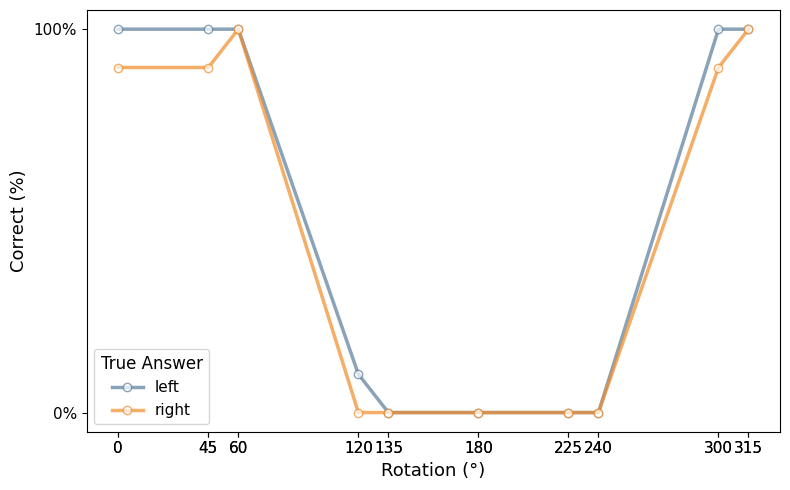

In [25]:
# plot base_correct as function of angles, color based on whether the true answer is left or right
# create a dataframe with angles, base_correct, and true_answers
df = pd.DataFrame({
    'angles': angles_plot,
    'base_correct': avg_base_correct,
    'true_answers': true_answers_plot
})

# Define your color map
custom_colors = {
    'left': '#5A7D9A',
    'right': '#F28C28'
}

plt.figure(figsize=(8, 5))
for label, group in df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['base_correct'], '-o', label=label,
             color=color, alpha=0.7, linewidth=2.5, markerfacecolor='white')

plt.xlabel('Rotation (°)', fontsize=13)
plt.ylabel('Correct (%)', fontsize=13)
#plt.title('LLaVA 1.5 13B (Base Model) - Perspective Taking')
plt.legend(title='True Answer', fontsize=11, title_fontsize=12)
plt.xticks(angles_plot)
# yticks should be *100 with % sign
plt.yticks([0, 1], ['0%', '100%'])
plt.tick_params(axis='both', labelsize=11)
plt.grid(False)
plt.tight_layout()

plt.savefig("data/evals/visuals/vpt_avatar_answers_base.png", dpi=300, bbox_inches='tight')

plt.show()

### VIT results

In [26]:
vit_results = {}

for n in range(10):
    vit_results_path = f"data/evals/perspective_taking/answers/repeats/vpt_avatar_answers_vit{n}.jsonl"
    with open(vit_results_path, "r") as f:
        name = f"vit_results_{n}"
        vit_results[name] = [json.loads(line) for line in f.readlines()]

In [27]:
vit_correct = {}

for name, results in vit_results.items():
    vit_answers = extract_answer(results)
    correct = [pred == true for pred, true in zip(vit_answers, true_answers)]
    vit_correct[name] = correct

In [28]:
avg_vit_correct = np.mean(list(vit_correct.values()), axis=0)

if with_perp == False:
    avg_vit_correct = [avg_vit_correct[i] for i in range(len(avg_vit_correct)) if i not in perp_index]
print("Average accuracy across 10 ViT models:", avg_vit_correct)

Average accuracy across 10 ViT models: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [29]:
print("average total accuracy:", np.mean(avg_vit_correct))

average total accuracy: 0.95


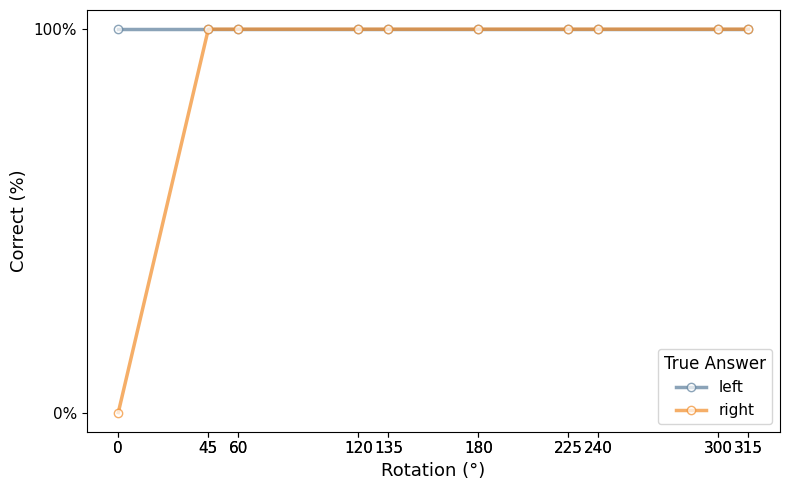

In [30]:
# add checkpoint_correct to the dataframe
df['vit_correct'] = avg_vit_correct

plt.figure(figsize=(8, 5))
for label, group in df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['vit_correct'], '-o', label=label,
             color=color, alpha=0.7, linewidth=2.5, markerfacecolor='white')

plt.xlabel('Rotation (°)', fontsize=13)
plt.ylabel('Correct (%)', fontsize=13)
#plt.title('LLaVA 1.5 13B (Base Model) - Perspective Taking')
plt.legend(title='True Answer', fontsize=11, title_fontsize=12)
plt.xticks(angles_plot)
# yticks should be *100 with % sign
plt.yticks([0, 1], ['0%', '100%'])
plt.tick_params(axis='both', labelsize=11)
plt.grid(False)
plt.tight_layout()

plt.savefig("data/evals/visuals/vpt_avatar_answers_vit.png", dpi=300, bbox_inches='tight')

plt.show()


### COCO results

In [31]:
coco_results = {}

for n in range(1):
    coco_results_path = f"data/evals/perspective_taking/answers/repeats/vpt_avatar_answers_coco{n}.jsonl"
    with open(coco_results_path, "r") as f:
        name = f"coco_results_{n}"
        coco_results[name] = [json.loads(line) for line in f.readlines()]

In [32]:
coco_correct = {}

for name, results in coco_results.items():
    coco_answers = extract_answer(results)
    correct = [pred == true for pred, true in zip(coco_answers, true_answers)]
    coco_correct[name] = correct

In [33]:
avg_coco_correct = np.mean(list(coco_correct.values()), axis=0)
if with_perp == False:
    avg_coco_correct = [avg_coco_correct[i] for i in range(len(avg_coco_correct)) if i not in perp_index]
print("Average accuracy across 10 COCO models:", avg_coco_correct)

Average accuracy across 10 COCO models: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [34]:
print("Average total accuracy:", np.mean(avg_coco_correct))

Average total accuracy: 1.0


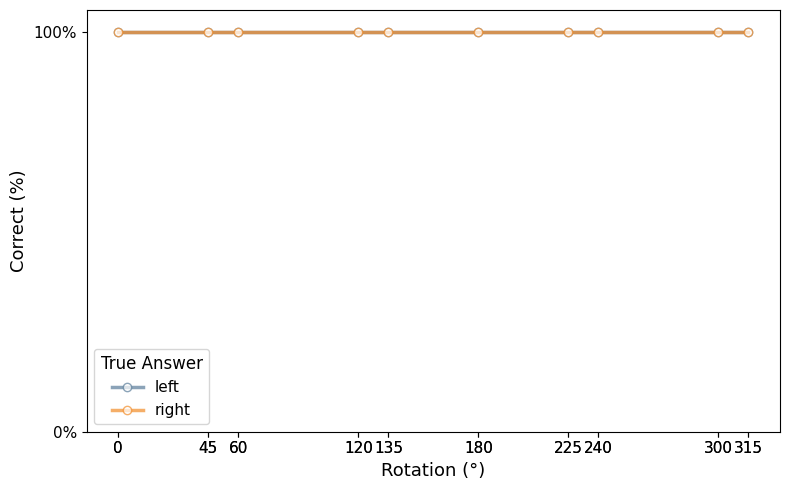

In [35]:
# add checkpoint_correct to the dataframe
df['coco_correct'] = avg_coco_correct

plt.figure(figsize=(8, 5))
for label, group in df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['coco_correct'], '-o', label=label,
             color=color, alpha=0.7, linewidth=2.5, markerfacecolor='white')

plt.xlabel('Rotation (°)', fontsize=13)
plt.ylabel('Correct (%)', fontsize=13)
#plt.title('LLaVA 1.5 13B (Base Model) - Perspective Taking')
plt.legend(title='True Answer', fontsize=11, title_fontsize=12)
plt.xticks(angles_plot)
# yticks should be *100 with % sign
plt.yticks([0, 1], ['0%', '100%'])
plt.tick_params(axis='both', labelsize=11)
plt.grid(False)
plt.tight_layout()

plt.savefig("data/evals/visuals/vpt_avatar_answers_coco.png", dpi=300, bbox_inches='tight')

plt.show()


# Pose tokens

In [36]:
pose_tokens_trained_path = f"data/evals/pose_tokens/answers/tokens_avatar_answers_vitpose.jsonl"

with open(pose_tokens_trained_path, "r") as f:
    pose_tokens_trained_results = [json.loads(line) for line in f.readlines()]

pose_tokens_trained_results[:3]

[{'question_id': 0,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_166> <Y_177> <CONF_9> <SHOULDER_R> <X_179> <Y_183> <CONF_9> <HIP_L> <X_166> <Y_210> <CONF_8> <HIP_R> <X_177> <Y_212> <CONF_8> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>',
  'answer_id': 'KwDoQkuzUwQMuMdXiBp7ab',
  'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora_checkpoint-4000',
  'metadata': {}},
 {'question_id': 1,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_169> <Y_177> <CONF_9> <SHOULDER_R> <X_184> <Y_177> <CONF_9> <HIP_L> <X_169> <Y_219> <CONF_8> <HIP_R> <X_182> <Y_220> <CONF_8> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>',
  'answer_id': 'UuFGpDLQ8V5zv8SSkHd5uT',
  'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora_checkpoint-4000',
  'metadata': {}},
 {'question_id': 2,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_166> <Y_185> <CONF_9> 

In [37]:
def plot_pose_on_image(pose_tokens: str, image_path: str, ax=None, coco=False):

    keypoint_names = {"SHOULDER_L", "SHOULDER_R", "HIP_L", "HIP_R"}
    tokens = pose_tokens.split()

    # Parse pose data and yaw
    pose_data = {}
    yaw_value = None
    i = 0
    while i < len(tokens):
        token = tokens[i]
        if token.startswith("<YAW_") and token.endswith(">"):
            yaw_value = int(token[5:-1])
        elif token.startswith("<") and token.endswith(">"):
            part = token[1:-1]
            if part in keypoint_names:
                try:
                    x = int(tokens[i+1][3:-1])
                    y = int(tokens[i+2][3:-1])
                    if not coco:
                        conf = int(tokens[i+3][6:-1])
                        pose_data[part] = (x, y, conf)
                        i += 4
                    else:
                        pose_data[part] = (x, y)
                        i += 3
                    continue
                except (IndexError, ValueError):
                    pass
        i += 1

    def yaw_to_degrees(yaw):
        if yaw is None:
            return "YAW_? (?)"
        low = yaw * 45
        high = low + 45
        return f"YAW_{yaw} ({low}°–{high}°)"

    yaw_title = yaw_to_degrees(yaw_value)

    # Load and resize image
    img = Image.open(image_path).convert("RGB").resize((336, 336))

    # Use passed axis or create one
    if ax is None:
        fig, ax = plt.subplots()

    ax.imshow(img)
    if not coco:
        for part, (x, y, conf) in pose_data.items():
            color = "#00B3B3" if "_L" in part else "#FF5E5B"
            y_text = y + 5 if "_L" in part else y - 5
            ax.scatter(x, y, c=color, s=10)
            ax.text(x + 3, y_text, part, fontsize=6, color=color)
    else:
        for part, (x, y) in pose_data.items():
            color = "#00B3B3" if "_L" in part else "#FF5E5B"
            y_text = y + 5 if "_L" in part else y - 5
            ax.scatter(x, y, c=color, s=10)
            ax.text(x + 3, y_text, part, fontsize=6, color=color)
    ax.set_xlim(0, 336)
    ax.set_ylim(336, 0)
    ax.set_title(yaw_title, fontsize=9)
    ax.axis("off")

In [38]:
image_dir = "data/evals/pose_tokens/images/"
images = os.listdir(image_dir)
# organize the images by 0, 45, 90, 135, 180, 225, 270, 315
images = sorted(images, key=lambda x: int(re.search(r'(\d+)', x).group(0)))
# organize images left first, then right (right now they're mixed by angle), left is even, right is odd
left_images = images[::2]
right_images = images[1::2]
images = left_images + right_images

In [39]:
pose_tokens = [item.get('text') for item in pose_tokens_trained_results]
pose_tokens[:3]

['<POSE_START> <SHOULDER_L> <X_166> <Y_177> <CONF_9> <SHOULDER_R> <X_179> <Y_183> <CONF_9> <HIP_L> <X_166> <Y_210> <CONF_8> <HIP_R> <X_177> <Y_212> <CONF_8> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>',
 '<POSE_START> <SHOULDER_L> <X_169> <Y_177> <CONF_9> <SHOULDER_R> <X_184> <Y_177> <CONF_9> <HIP_L> <X_169> <Y_219> <CONF_8> <HIP_R> <X_182> <Y_220> <CONF_8> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>',
 '<POSE_START> <SHOULDER_L> <X_166> <Y_185> <CONF_9> <SHOULDER_R> <X_177> <Y_183> <CONF_9> <HIP_L> <X_166> <Y_213> <CONF_8> <HIP_R> <X_173> <Y_213> <CONF_8> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>']

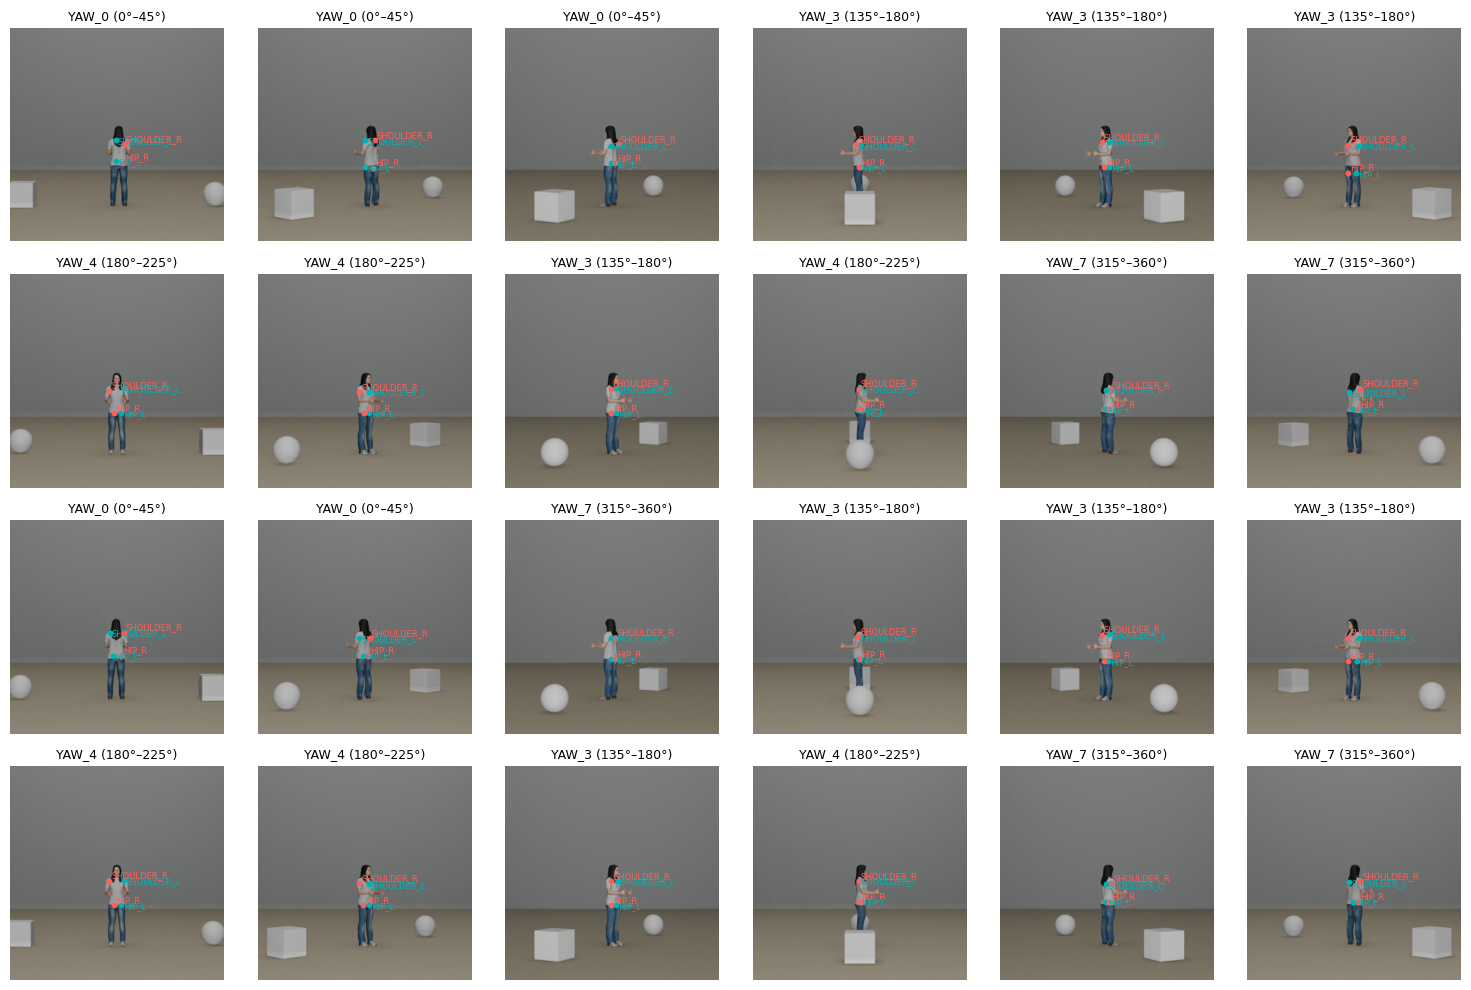

In [40]:
import os
import matplotlib.pyplot as plt

n_rows, n_cols = 4, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))

for i in range(n_rows * n_cols):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]
    image_path = os.path.join(image_dir, images[i])
    plot_pose_on_image(pose_tokens[i], image_path, ax=ax, coco=False)

plt.tight_layout()

plt.savefig("data/evals/visuals/vpt_pose_tokens_trained.png", dpi=300, bbox_inches='tight')

plt.show()


In [41]:
pose_tokens_trained_path_coco = f"data/evals/pose_tokens/answers/tokens_avatar_answers_coco.jsonl"

with open(pose_tokens_trained_path_coco, "r") as f:
    pose_tokens_trained_results_coco = [json.loads(line) for line in f.readlines()]

pose_tokens_trained_results_coco[:3]

[{'question_id': 0,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_158> <Y_181> <SHOULDER_R> <X_180> <Y_179> <HIP_L> <X_168> <Y_212> <HIP_R> <X_178> <Y_214> <ORIENT_START> <YAW_0> <TORSO_W_2> <ORIENT_END> <POSE_END>',
  'answer_id': 'n8ihiedf6e7f8nG8SUwLrt',
  'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora',
  'metadata': {}},
 {'question_id': 1,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_175> <Y_176> <SHOULDER_R> <X_190> <Y_179> <HIP_L> <X_174> <Y_212> <HIP_R> <X_183> <Y_213> <ORIENT_START> <YAW_7> <TORSO_W_1> <ORIENT_END> <POSE_END>',
  'answer_id': 'GZkPcyrbPMsi6ABsLpHo8q',
  'model_id': 'train_perspective_annealing-llava-v1.5-13b-task-lora',
  'metadata': {}},
 {'question_id': 2,
  'prompt': "Estimate this person's pose.",
  'text': '<POSE_START> <SHOULDER_L> <X_163> <Y_180> <SHOULDER_R> <X_176> <Y_179> <HIP_L> <X_166> <Y_213> <HIP_R> <X_178> <Y_216> <ORIENT_START> <YAW_0> <TORSO_W_1> <

In [42]:
coco_pose_tokens = [item.get('text') for item in pose_tokens_trained_results_coco]
coco_pose_tokens[:3]

['<POSE_START> <SHOULDER_L> <X_158> <Y_181> <SHOULDER_R> <X_180> <Y_179> <HIP_L> <X_168> <Y_212> <HIP_R> <X_178> <Y_214> <ORIENT_START> <YAW_0> <TORSO_W_2> <ORIENT_END> <POSE_END>',
 '<POSE_START> <SHOULDER_L> <X_175> <Y_176> <SHOULDER_R> <X_190> <Y_179> <HIP_L> <X_174> <Y_212> <HIP_R> <X_183> <Y_213> <ORIENT_START> <YAW_7> <TORSO_W_1> <ORIENT_END> <POSE_END>',
 '<POSE_START> <SHOULDER_L> <X_163> <Y_180> <SHOULDER_R> <X_176> <Y_179> <HIP_L> <X_166> <Y_213> <HIP_R> <X_178> <Y_216> <ORIENT_START> <YAW_0> <TORSO_W_1> <ORIENT_END> <POSE_END>']

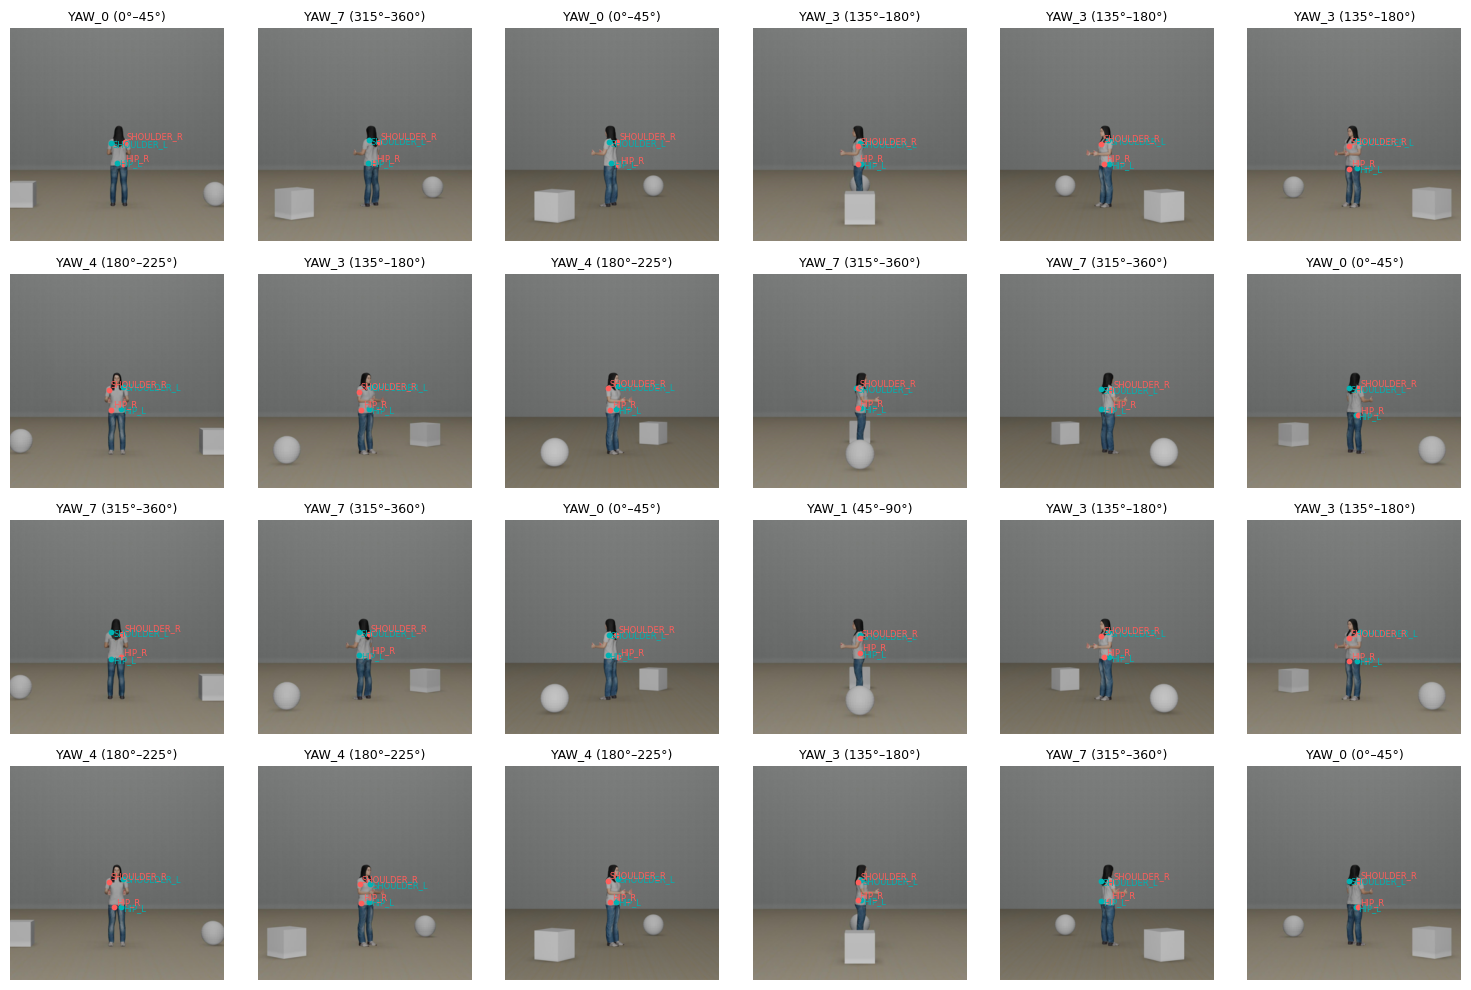

In [43]:
n_rows, n_cols = 4, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))

for i in range(n_rows * n_cols):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]
    image_path = os.path.join(image_dir, images[i])
    plot_pose_on_image(coco_pose_tokens[i], image_path, ax=ax, coco=True)

plt.tight_layout()

plt.savefig("data/evals/visuals/vpt_pose_tokens_trained_coco.png", dpi=300, bbox_inches='tight')

plt.show()

### Chain of thought
Why, if the yaw is in the correct alignment, does perception llava not correclty answer right-cube at 0°? Let's look at it's responses when we do chain of thought prompting...

In [44]:
vit_cot_answers_path = f"data/evals/perspective_taking/answers/vpt_avatar_answers_vitpose_cot.jsonl"

with open(vit_cot_answers_path, "r") as f:
    vit_cot_results = [json.loads(line) for line in f.readlines()]

In [55]:
vit_cot_final_answers = [item.get('text').split("Therefore, the cube is to the ")[1].split(" from the perspective of the person")[0] for item in vit_cot_results]
vit_cot_final_answers[:3]

['left', 'left', 'left']

In [57]:
if with_perp == False:
    vit_cot_correct = [1 if vit_cot_final_answers[i] == true_answers[i] else 0 for i in range(len(vit_cot_final_answers)) if i not in perp_index]
else:
    vit_cot_correct = [1 if vit_cot_final_answers[i] == true_answers[i] else 0 for i in range(len(vit_cot_final_answers))]
vit_cot_correct[:3]

[1, 1, 1]

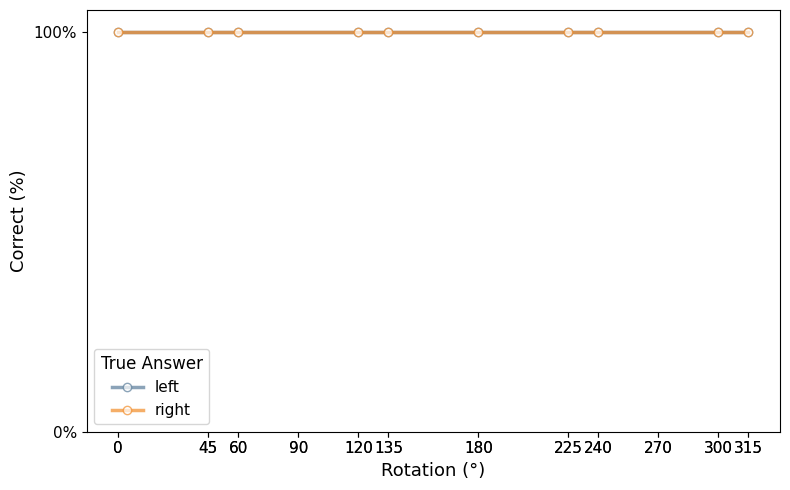

In [58]:
# now plot
df['vit_cot_correct'] = vit_cot_correct
plt.figure(figsize=(8, 5))

for label, group in df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['vit_cot_correct'], '-o', label=label,
             color=color, alpha=0.7, linewidth=2.5, markerfacecolor='white')
plt.xlabel('Rotation (°)', fontsize=13)
plt.ylabel('Correct (%)', fontsize=13)
#plt.title('LLaVA 1.5 13B with Perspective Tokens (CoT response) - Perspective Taking')
plt.legend(title='True Answer', fontsize=11, title_fontsize=12)
plt.xticks(angles)
plt.yticks([0, 1], ['0%', '100%'])
plt.tick_params(axis='both', labelsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig("data/evals/visuals/vpt_avatar_answers_vit_CoT.png", dpi=300, bbox_inches='tight')
plt.show()

In [59]:
cot_coco_answers_path = f"data/evals/perspective_taking/answers/vpt_avatar_answers_coco_cot.jsonl"

with open(cot_coco_answers_path, "r") as f:
    cot_coco_results = [json.loads(line) for line in f.readlines()]

In [60]:
cot_coco_results[0].get('text').split("Therefore, the cube is to the ")[1].split(" from the perspective of the person")[0]

'left'

In [61]:
coco_cot_final_answers = [
    resp.get('text').split("Therefore, the cube is to the ")[1].split(" from the perspective of the person")[0]
    if "Therefore, the cube is to the " in resp.get('text')
    else "unknown"
    for resp in cot_coco_results
]
coco_cot_final_answers[:3]

['left', 'left', 'left']

In [64]:
if with_perp == False:
    coco_cot_correct = [1 if coco_cot_final_answers[i] == true_answers[i] else 0 for i in range(len(coco_cot_final_answers)) if i not in perp_index]
else:
    coco_cot_correct = [1 if coco_cot_final_answers[i] == true_answers[i] else 0 for i in range(len(coco_cot_final_answers))]
coco_cot_correct[:3]

[1, 1, 1]

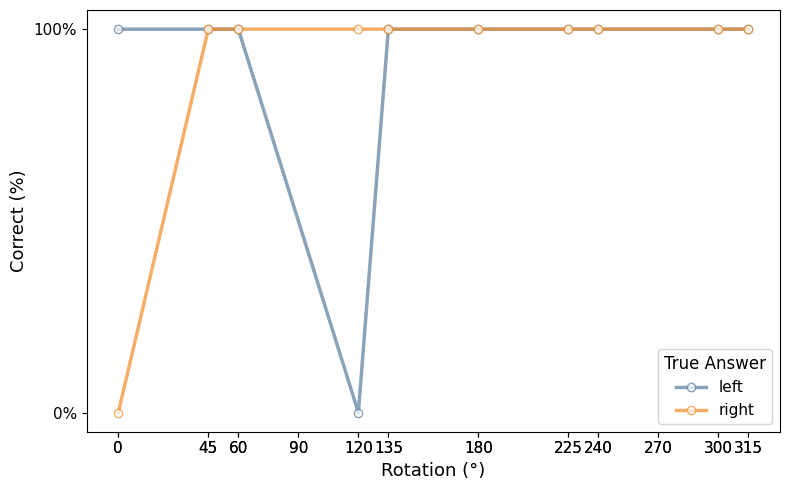

In [65]:
# now plot
df['coco_cot_correct'] = coco_cot_correct
plt.figure(figsize=(8, 5))

for label, group in df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['coco_cot_correct'], '-o', label=label,
             color=color, alpha=0.7, linewidth=2.5, markerfacecolor='white')
plt.xlabel('Rotation (°)', fontsize=13)
plt.ylabel('Correct (%)', fontsize=13)
#plt.title('LLaVA 1.5 13B with Pose Tokens (COCO - CoT response) - Perspective Taking')
plt.legend(title='True Answer', fontsize=11, title_fontsize=12)
plt.xticks(angles)
plt.yticks([0, 1], ['0%', '100%'])
plt.tick_params(axis='both', labelsize=11)
plt.grid(False)
plt.tight_layout()
plt.savefig("data/evals/visuals/vpt_avatar_answers_coco_CoT.png", dpi=300, bbox_inches='tight')
plt.show()

#### What about a model with text tokens?

In [66]:
text_tokens_path = f"data/evals/perspective_taking/answers/vpt_avatar_answers_text_vitpose.jsonl"

with open(text_tokens_path, "r") as f:
    text_tokens_results = [json.loads(line) for line in f.readlines()]

In [67]:
text_tokens_results[:3]

[{'question_id': 0,
  'prompt': "A person and a cube are shown in the image. Which side of the person is the cube on from the person's perspective?",
  'text': 'left',
  'answer_id': 'F4cWX8EF6Ajrz3owuKmPaY',
  'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT',
  'metadata': {}},
 {'question_id': 1,
  'prompt': "A person and a cube are shown in the image. Which side of the person is the cube on from the person's perspective?",
  'text': 'left',
  'answer_id': 'GoZLMXgbojFbyvo46NPMB3',
  'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT',
  'metadata': {}},
 {'question_id': 2,
  'prompt': "A person and a cube are shown in the image. Which side of the person is the cube on from the person's perspective?",
  'text': 'left',
  'answer_id': 'jBVMpswEu5LaPuKTeNuUji',
  'model_id': 'train_text_annealing-llava-v1.5-13b-task-lora-ViT',
  'metadata': {}}]

In [68]:
text_answers = ['left'] * 8 + ['right'] * 8

In [71]:
if with_perp == False:
    text_correct = [1 if text_tokens_results[i].get('text') == true_answers[i] else 0 for i in range(len(text_tokens_results)) if i not in perp_index]
else:
    text_correct = [1 if text_tokens_results[i].get('text') == true_answers[i] else 0 for i in range(len(text_tokens_results))]
text_correct[:3]

[1, 1, 1]

In [72]:
len(text_correct), len(angles), len(true_answers)

(20, 24, 24)

In [75]:
text_df = pd.DataFrame({
    'angles': angles_plot,
    'text_correct': text_correct,
    'true_answers': true_answers_plot
})

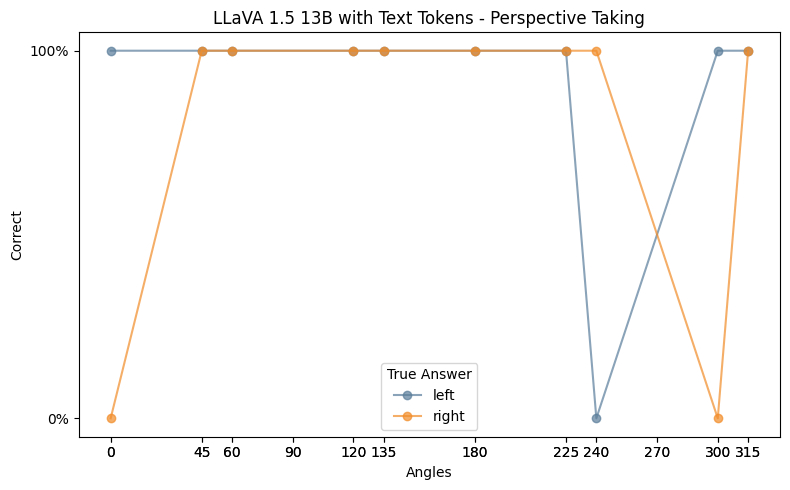

In [76]:
# now plot
plt.figure(figsize=(8, 5))

for label, group in text_df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['text_correct'], marker='o', label=label,
             color=color, alpha=0.7)
plt.xlabel('Angles')
plt.ylabel('Correct')
plt.title('LLaVA 1.5 13B with Text Tokens - Perspective Taking')
plt.legend(title='True Answer')
plt.xticks(angles)
plt.yticks([0, 1], ['0%', '100%'])
plt.grid(False)
plt.tight_layout()
plt.savefig("data/evals/visuals/vpt_avatar_answers_text.png", dpi=300, bbox_inches='tight')
plt.show()

#### Text with CoT

In [ ]:
text_cot_path = f"data/evals/perspective_taking/answers/vpt_avatar_answers_text_vitpose_CoT.jsonl"

with open(text_cot_path, "r") as f:
    text_cot_results = [json.loads(line) for line in f.readlines()]

In [ ]:
text_cot_answers = [answer.get('text') for answer in text_cot_results]
text_cot_answers[:3]

["The cube is left of the person from the viewer's frame. The person's pose is 162.0 177.0 0.9 181.0 179.0 0.9 165.0 210.0 0.8 177.0 211.0 0.8 7 1. Since 7 lies in the 315-360 bin, the person is aligned. After performing a mental rotation of 315-360 degrees, the cube is now to the left. Therefore, the cube is to the left from the perspective of the person.",
 "The cube is left of the person from the viewer's frame. The person's pose is 176.0 173.0 0.9 197.0 174.0 0.9 179.0 209.0 0.8 190.0 210.0 0.8 7 1. Since 7 lies in the 315-360 bin, the person is aligned. After performing a mental rotation of 315-360 degrees, the cube is now to the left. Therefore, the cube is to the left from the perspective of the person.",
 "The cube is left of the person from the viewer's frame. The person's pose is 169.0 178.0 0.9 168.0 177.0 0.8 170.0 209.0 0.8 169.0 209.0 0.7 2 0. Since 2 lies in the 90-135 bin, the person is unaligned. After performing a mental rotation of 90-135 degrees, the cube is now to 

In [ ]:
text_cot_final = [str.split("Therefore, the cube is to the ")[1].split(" from the perspective of the person")[0] for str in text_cot_answers]
text_cot_final[:3]

['left', 'left', 'right']

In [ ]:
text_cot_correct = [1 if text_cot_final[i] == true_answers[i] else 0 for i in range(len(text_cot_final))]
text_cot_correct[:3]

[1, 1, 0]

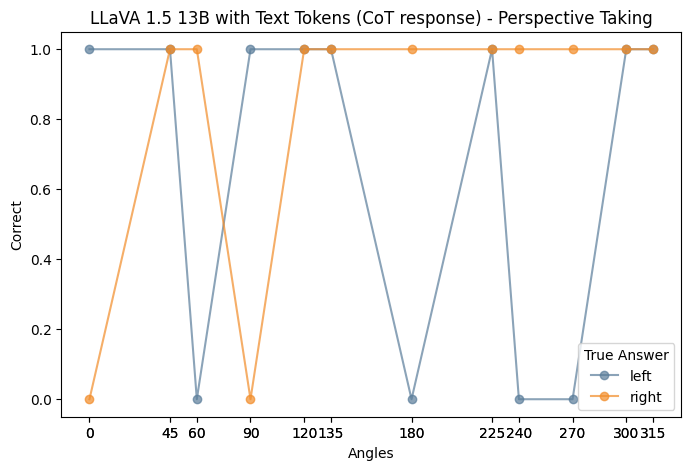

In [ ]:
text_df['text_cot_correct'] = text_cot_correct
plt.figure(figsize=(8, 5))
for label, group in text_df.groupby('true_answers'):
    color = custom_colors.get(label, 'gray')  # fallback to gray if label is unexpected
    plt.plot(group['angles'], group['text_cot_correct'], marker='o', label=label,
             color=color, alpha=0.7)
plt.xlabel('Angles')
plt.xticks(angles)
plt.ylabel('Correct')
plt.title('LLaVA 1.5 13B with Text Tokens (CoT response) - Perspective Taking')
plt.legend(title='True Answer')